🚀 Processing All Labs... Please Wait

LAB 1: Image to Array & Basic Information
Shape (H × W × C): (1080, 1920, 3)
Data Type: uint8
Min Pixel: 0 | Max Pixel: 255

LAB 2: Grayscale Conversion
LAB 3: Negative Transformation
LAB 4: Gamma Transformation
LAB 5: Histogram Equalization
LAB 6: Mini Project - Combined Enhancement

✅ All Labs Completed! Results saved in 'DIP_Results' folder.

📊 SIDE-BY-SIDE COMPARISON DASHBOARD


/tmp/ipykernel_858/2313378685.py:135: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0,256], color='blue', alpha=0.7)
/tmp/ipykernel_858/2313378685.py:139: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(enhanced.ravel(), 256, [0,256], color='green', alpha=0.7)


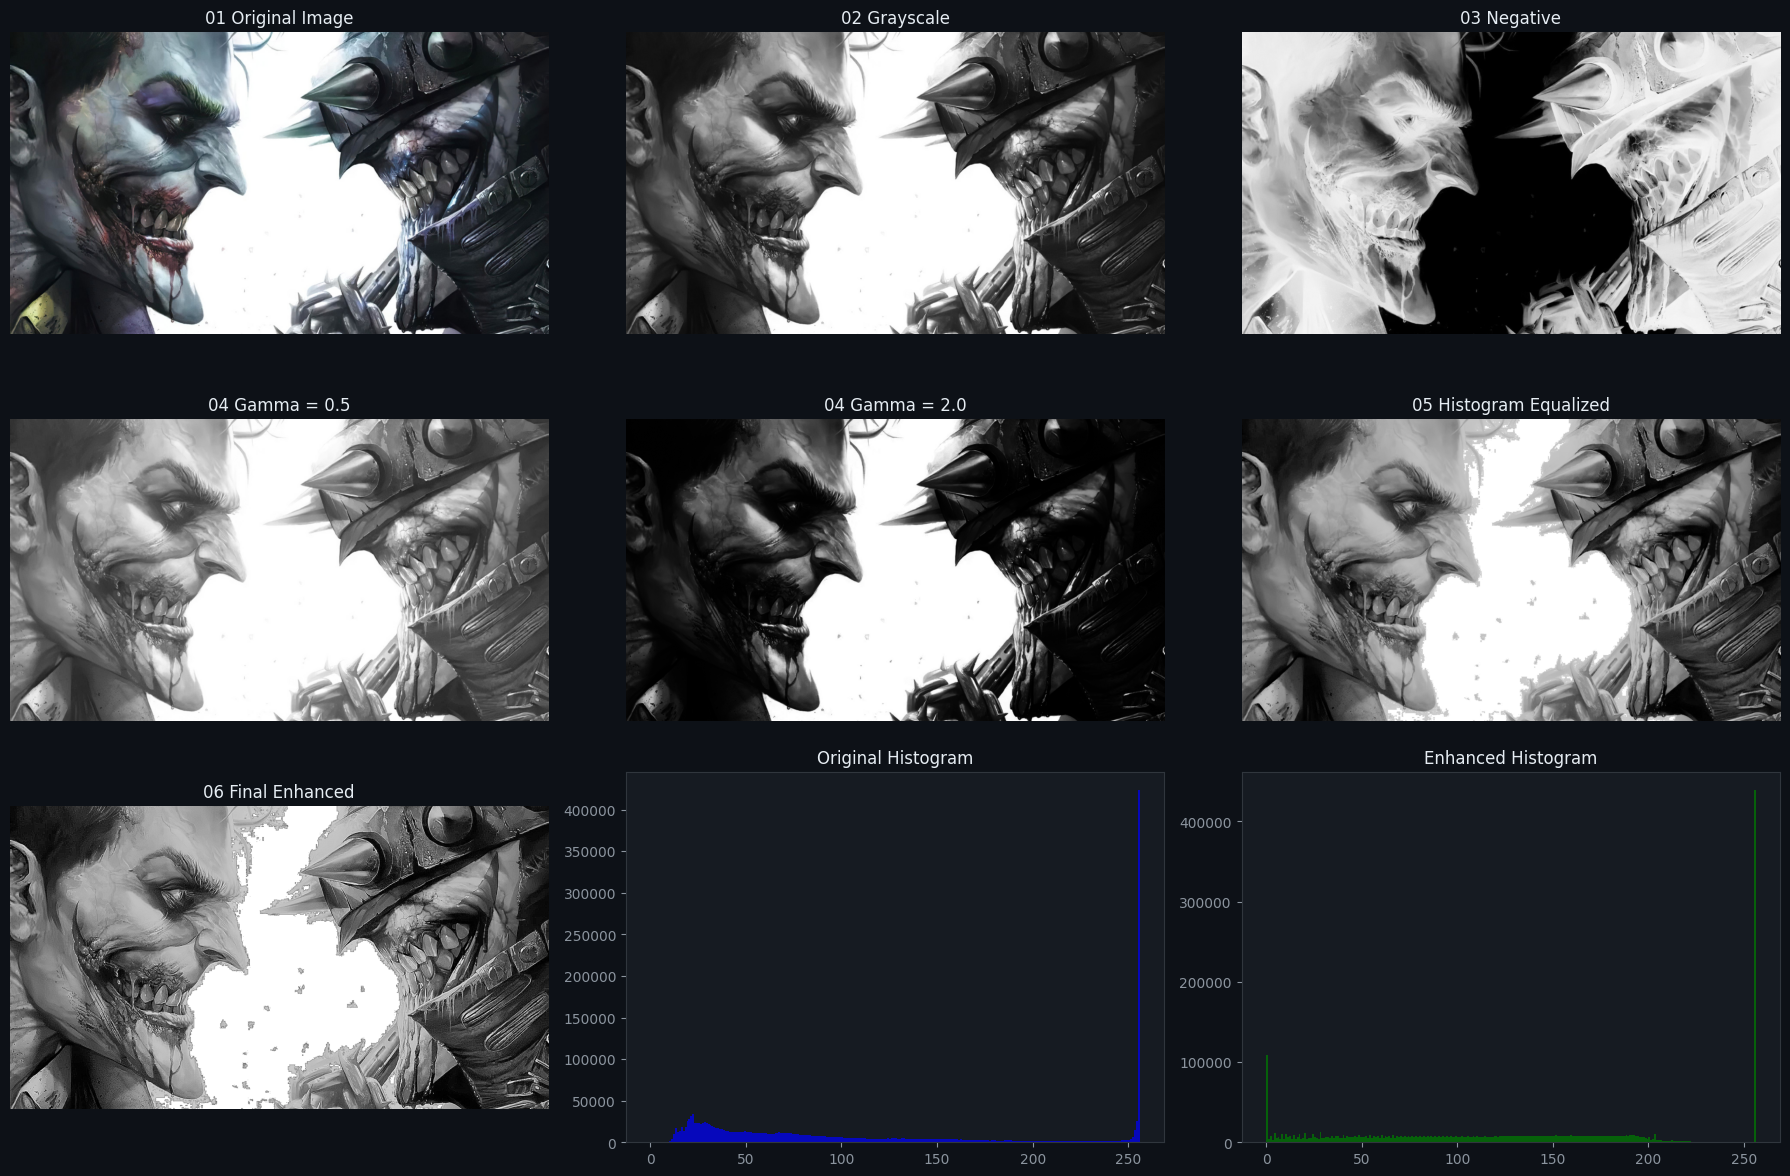

📥 Download link for all images:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# =====================================================
# ImageMaster Pro - Complete DIP Lab Final Project
# Enhanced with One-Button Execution + Dashboard
# =====================================================

!pip install opencv-python matplotlib numpy ipywidgets -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import os

# Create output directory
os.makedirs("DIP_Results", exist_ok=True)
print("✅ Setup Complete! Upload your image below.")

# ====================== UPLOAD ======================
uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

# ====================== MAIN PROCESSING FUNCTION ======================
def run_all_labs(b):
    clear_output(wait=True)
    if not uploader.value:
        print("❌ Please upload an image first!")
        display(uploader)
        return

    # Get uploaded file
    uploaded_file = list(uploader.value.values())[0]
    with open('input_image.jpg', 'wb') as f:
        f.write(uploaded_file['content'])

    img = cv2.imread('input_image.jpg')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    print("🚀 Processing All Labs... Please Wait")

    # ====================== LAB 1 ======================
    print("\n" + "="*70)
    print("LAB 1: Image to Array & Basic Information")
    print("="*70)
    print(f"Shape (H × W × C): {img.shape}")
    print(f"Data Type: {img.dtype}")
    print(f"Min Pixel: {img.min()} | Max Pixel: {img.max()}")

    cv2.imwrite("DIP_Results/01_Original.jpg", img)

    # ====================== LAB 2 ======================
    print("\nLAB 2: Grayscale Conversion")
    cv2.imwrite("DIP_Results/02_Grayscale.jpg", gray)

    # ====================== LAB 3 ======================
    print("LAB 3: Negative Transformation")
    negative = 255 - gray
    cv2.imwrite("DIP_Results/03_Negative.jpg", negative)

    # ====================== LAB 4 ======================
    print("LAB 4: Gamma Transformation")
    def gamma_correction(image, gamma):
        image_norm = image / 255.0
        corrected = np.power(image_norm, gamma)
        return np.clip(corrected * 255, 0, 255).astype(np.uint8)

    gamma05 = gamma_correction(gray, 0.5)
    gamma20 = gamma_correction(gray, 2.0)
    cv2.imwrite("DIP_Results/04_Gamma_0.5.jpg", gamma05)
    cv2.imwrite("DIP_Results/04_Gamma_2.0.jpg", gamma20)

    # ====================== LAB 5 ======================
    print("LAB 5: Histogram Equalization")
    equalized = cv2.equalizeHist(gray)
    cv2.imwrite("DIP_Results/05_Equalized.jpg", equalized)

    # ====================== LAB 6 ======================
    print("LAB 6: Mini Project - Combined Enhancement")
    enhanced = gamma_correction(gray, 0.8)
    enhanced = cv2.equalizeHist(enhanced)
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    enhanced = cv2.filter2D(enhanced, -1, kernel)
    cv2.imwrite("DIP_Results/06_Final_Enhanced.jpg", enhanced)

    print("\n✅ All Labs Completed! Results saved in 'DIP_Results' folder.")

    # ====================== DASHBOARD ======================
    print("\n" + "="*70)
    print("📊 SIDE-BY-SIDE COMPARISON DASHBOARD")
    print("="*70)

    fig = plt.figure(figsize=(18, 12))

    # Row 1
    plt.subplot(3, 3, 1)
    plt.imshow(img_rgb)
    plt.title("01 Original Image")
    plt.axis('off')

    plt.subplot(3, 3, 2)
    plt.imshow(gray, cmap='gray')
    plt.title("02 Grayscale")
    plt.axis('off')

    plt.subplot(3, 3, 3)
    plt.imshow(negative, cmap='gray')
    plt.title("03 Negative")
    plt.axis('off')

    # Row 2
    plt.subplot(3, 3, 4)
    plt.imshow(gamma05, cmap='gray')
    plt.title("04 Gamma = 0.5")
    plt.axis('off')

    plt.subplot(3, 3, 5)
    plt.imshow(gamma20, cmap='gray')
    plt.title("04 Gamma = 2.0")
    plt.axis('off')

    plt.subplot(3, 3, 6)
    plt.imshow(equalized, cmap='gray')
    plt.title("05 Histogram Equalized")
    plt.axis('off')

    # Row 3
    plt.subplot(3, 3, 7)
    plt.imshow(enhanced, cmap='gray')
    plt.title("06 Final Enhanced")
    plt.axis('off')

    plt.subplot(3, 3, 8)
    plt.hist(gray.ravel(), 256, [0,256], color='blue', alpha=0.7)
    plt.title("Original Histogram")

    plt.subplot(3, 3, 9)
    plt.hist(enhanced.ravel(), 256, [0,256], color='green', alpha=0.7)
    plt.title("Enhanced Histogram")

    plt.tight_layout()
    plt.show()

    # Download all results as ZIP
    !zip -r DIP_Results.zip DIP_Results > /dev/null
    print("📥 Download link for all images:")
    files.download('DIP_Results.zip')

# ====================== ONE BUTTON ======================
button = widgets.Button(
    description="🚀 Run All Labs",
    button_style='success',
    layout=widgets.Layout(width='300px', height='60px')
)
button.on_click(run_all_labs)

display(button)